In [42]:
import pandas as pd                        
import random
import time
import matplotlib.pyplot as plt
import math

In [43]:
df_1000 = pd.read_csv(r"C:\Users\Lenovo\Desktop\DAS_lab_3\lab3\data\a_steam_data_1000.csv")
df_10000 = pd.read_csv(r"C:\Users\Lenovo\Desktop\DAS_lab_3\lab3\data\a_steam_data_10000.csv")
df_50000 = pd.read_csv(r"C:\Users\Lenovo\Desktop\DAS_lab_3\lab3\data\a_steam_data_50000.csv")
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\DAS_lab_3\lab3\data\a_steam_data_2021_2025.csv")
df_1000_sorted = df_1000.sort_values(by="appid")
df_10000_sorted = df_10000.sort_values(by="appid")
df_50000_sorted = df_50000.sort_values(by="appid")


df["release_date"] = pd.to_datetime(df_50000["release_date"], errors="coerce", format="mixed")
dff = df.dropna(subset=["release_date"])

In [44]:
num_1000 = random.randint(1, 1000)
target = df_1000["appid"].iloc[num_1000]
keys = df_1000["appid"].tolist()
keys_sorted = df_1000_sorted["appid"].tolist()

**TASK 1**

In [45]:
def Linear_search(arr, target):
    for _ in range(len(arr)):
        if arr[_]==target:
            return _
    return -1


result = Linear_search(keys, target)

if result != -1:
  print(result)
else:
  print("Not found")


501


In [46]:
def binarySearch(arr, target):
  left = 0
  right = len(arr) - 1

  while left <= right:
    mid = (left + right) // 2

    if arr[mid] == target:
      return mid

    if arr[mid] < target:
      left = mid + 1
    else:
      right = mid - 1

  return -1

result = binarySearch(keys_sorted, target)

if result != -1:
  print(result)
else:
  print("Not found")

338


In [47]:
def jumpSearch(arr, x, n):
    
    step = math.sqrt(n)

    prev = 0
    while arr[int(min(step, n)-1)] < x:
        prev = step
        step += math.sqrt(n)
        if prev >= n:
            return -1

    while arr[int(prev)] < x:
        prev += 1
        
        if prev == min(step, n):
            return -1
    

    if arr[int(prev)] == x:
        return prev
    
    return -1


index = jumpSearch(keys_sorted, target, len(keys))

if index % 1 >=0.5:
    print(f"{(index-1):.0f}")
else:
    print(f"{index:.0f}")


338


In [48]:
def interpolationSearch(arr, lo, hi, x):
    if lo <= hi and x >= arr[lo] and x <= arr[hi]:

        if arr[hi] == arr[lo]:
            if arr[lo] == x:
                return lo
            return -1

        pos = lo + int((hi - lo) / (arr[hi] - arr[lo]) * (x - arr[lo]))

        if pos < 0 or pos >= len(arr):
            return -1

        if arr[pos] == x:
            return pos

        if arr[pos] < x:
            return interpolationSearch(arr, pos + 1, hi, x)

        if arr[pos] > x:
            return interpolationSearch(arr, lo, pos - 1, x)

    return -1



index = interpolationSearch(keys_sorted, 0, len(keys) - 1, target)

if index != -1:
    print(index)
else:
    print("Element not found")


338


In [49]:
key_col = "appid"
num_1000 = random.randint(1, 1000)
num_10000 = random.randint(1, 10000)
num_50000 = random.randint(1, 50000)
target_1000 = df_1000[key_col].iloc[num_1000]
target_10000 = df_10000[key_col].iloc[num_10000]
target_50000 = df_50000[key_col].iloc[num_50000]
keys_1000 = df_1000[key_col].tolist()
keys_10000 = df_10000[key_col].tolist()
keys_50000 = df_50000[key_col].tolist()
keys_sorted_1000 = df_1000_sorted[key_col].tolist()
keys_sorted_10000 = df_10000_sorted[key_col].tolist()
keys_sorted_50000 = df_50000_sorted[key_col].tolist()


data = {
    1000: (keys_1000, target_1000),
    10000: (keys_10000, target_10000),
    50000: (keys_50000, target_50000)
}
data_sorted = {
    1000: (keys_sorted_1000, target_1000),
    10000: (keys_sorted_10000, target_10000),
    50000: (keys_sorted_50000, target_50000)
}


def measure_time(search, *args, repeat=3):
    start = time.perf_counter()
    for _ in range(repeat):
        search(*args)
    end = time.perf_counter()
    return (end - start)*1000/repeat



linear_times = []
for size, (keys, target) in data.items():
    t = measure_time(Linear_search, keys, target)
    linear_times.append(t)
    print(f"Time_n{size}_Linear: {t:.6f} ms")



binary_times = []
for size, (keys, target) in data_sorted.items():
    t = measure_time(binarySearch, keys, target)
    binary_times.append(t)
    print(f"Time_n{size}_binary: {t:.6f} ms")




jump_times = []
for size, (keys, target) in data_sorted.items():
    t = measure_time(jumpSearch, keys, target, len(keys))
    jump_times.append(t)
    print(f"Time_n{size}_jump: {t:.6f} ms")



interpolation_times = []
for size, (keys, target) in data_sorted.items():
    t = measure_time(interpolationSearch, keys, 0, len(keys)-1, target)
    interpolation_times.append(t)
    print(f"Time_n{size}_interpolation: {t:.6f} ms")


Time_n1000_Linear: 0.038800 ms
Time_n10000_Linear: 0.794767 ms
Time_n50000_Linear: 2.488633 ms
Time_n1000_binary: 0.004967 ms
Time_n10000_binary: 0.005267 ms
Time_n50000_binary: 0.005833 ms
Time_n1000_jump: 0.022133 ms
Time_n10000_jump: 0.039767 ms
Time_n50000_jump: 0.114500 ms
Time_n1000_interpolation: 0.031700 ms
Time_n10000_interpolation: 0.019600 ms
Time_n50000_interpolation: 0.025500 ms


Binary search wins at every size while Linear search is the slowest at each size

In [50]:
a = list(range(2976)) + [99999999999999]
print(a)

print(measure_time(binarySearch, a, 2975))


print(measure_time(interpolationSearch, a, 0, len(a)-1, 2975))



[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

Interpolation does good when all the numbers are close to each other, but in this case the last number distorts the equation and turn it into basically linear search


**TASK 2**

In [51]:
class Node:
    def __init__ (self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None


class BinarySearchTree:
    def __init__ (self):
        self.root = None
    
    def insert(self, key, value):
        self.root = self._insert(self.root, key, value)
    
    def _insert(self, node, key, value):
        if node is None:
            return Node(key, value)
        
        if key > node.key:
            node.right = self._insert(node.right, key, value)
            
        elif key < node.key:
            node.left = self._insert(node.left, key, value)
        else:
            node.value = value

        return node
    
              
    def search(self, key):
        node = self.root

        while node is not None:
            if node.key == key:
                return node.value
            elif node.key > key:
                node = node.left
            else:
                node = node.right 
        return None    
 
    def delete(self, key):
        self.root = self._delete(self.root, key)

    def _delete(self, node, key):
        if node is None:
            return None
        
        if key < node.key:
            node.left = self._delete(node.left, key)
        
        elif key > node.key:
            node.right = self._delete(node.right, key)

        else:
            if node.left is None and node.right is None:
                return None
            
            elif node.left is not None and node.right is None:
                return node.left
            
            elif node.left is None and node.right is not None:
                return node.right
            
            successor = self.min_node(node.right)
            node.key = successor.key
            node.value = successor.value
            node.right = self._delete(node.right, key)

        return node
    
    def min_node(self, node):
        while node.left is not None:
            node = node.left
        return node
    
    
    def inorder(self):
        result = []
        self._inorder(self.root, result)
        return result

    def _inorder(self, node, result):
        if node is not None:
            self._inorder(node.left, result)
            result.append((node.key, node.value))
            self._inorder(node.right, result)
    
    
    def preorder(self):
        result = []
        self._preorder(self.root, result)
        return result
    
    def _preorder(self, node, result):
        while node is not None:
            result.append((node.key, node.value))
            self._preorder(node.left, result)
            self._preorder(node.right, result)


    def postorder(self):
        result = []
        self._postorder(self.root, result)
        return result
    
    def _postorder(self, node, result):
        while node is not None:
            self._postorder(node.left, result)
            self._postorder(node.right, result)
            result.append((node.key, node.value))
    

    def bfs(self):
        if self.root is None:
            return []
        
        result = []
        queue = [self.root]
        
        while queue:
            node = queue.pop(0)
            result.append((node.key, node.value))

            if node.left is not None:
                queue.append(node.left)

            if node.right is not None:
                queue.append(node.right)
    

    def range_query(self, low, high):
        result = []
        self._range_query(self.root, low, high, result)
        return result

    def _range_query(self, node, low, high, result):
        if node is None:
            return

        if node.key > low:
            self._range_query(node.left, low, high, result)

        if low <= node.key <= high:
            result.append(node.value)

        if node.key < high:
            self._range_query(node.right, low, high, result)
    
    
    def depth(self):
        def helper(node):
            if node is None:
                return 0
            return 1 + max(helper(node.left), helper(node.right))
    
        return helper(self.root)
    

In [52]:
bst = BinarySearchTree()

#BST builder
for _, row in dff.iterrows():
    key = row["release_date"]
    bst.insert(key, row)

low = pd.to_datetime("2022-01-01")
high = pd.to_datetime("2022-12-31")



start = time.perf_counter()

bst_result = bst.range_query(low, high)

end = time.perf_counter()
print((end - start)*1000)
bst_time = (end - start)*1000





start = time.perf_counter()

baseline_result = []
for _, row in dff.iterrows():
    key = row["release_date"]
    if low <= key <= high:
        baseline_result.append(row)

end = time.perf_counter()
print((end - start)*1000)
lazy_baseline_time = (end - start)*1000

13.300299877300858
3576.1417001485825


**TASK 3**

In [53]:
class Heap:
    def __init__(self, key_col):
        self.data = []
        self.key_col = key_col

    def insert(self, value):
        self.data.append(value)
        self.bubble_up(len(self.data) - 1)

    def peek(self):
        return self.data[0]

    def extract(self):
        if len(self.data) == 0:
            return None

        if len(self.data) == 1:
            return self.data.pop()

        top = self.data[0]
        self.data[0] = self.data.pop()
        self.bubble_down(0)
        return top

    def bubble_up(self, index):
        while index > 0:
            parent = (index - 1) // 2

            if self.data[index][self.key_col] < self.data[parent][self.key_col]:
                self.data[index], self.data[parent] = self.data[parent], self.data[index]
                index = parent
            else:
                break

    def bubble_down(self, index):
        while True:
            left = 2 * index + 1
            right = 2 * index + 2
            smallest = index

            if left < len(self.data) and self.data[left][self.key_col] < self.data[smallest][self.key_col]:
                smallest = left

            if right < len(self.data) and self.data[right][self.key_col] < self.data[smallest][self.key_col]:
                smallest = right

            if smallest != index:
                self.data[index], self.data[smallest] = self.data[smallest], self.data[index]
                index = smallest
            else:
                break

In [54]:
k = 10
h = Heap("price")



start = time.perf_counter()

for _, row in df_50000.iterrows():
    if len(h.data) < k:
        h.insert(row)
    else:
        if row["price"] > h.peek()["price"]:
            h.extract()
            h.insert(row)

results = []

while len(h.data) > 0:
    results.append(h.extract())

results.reverse()

end = time.perf_counter()
print((end - start)*1000)
heap_time = (end - start)*1000

start = time.perf_counter()

top_10 = df_50000.sort_values(by="price")[-10:]

end = time.perf_counter()
print((end - start)*1000)
naive_time = (end - start)*1000

print(results)

3652.0165998954326
21.104800049215555
[appid                                                        2691920
name                                                   MolCollabo v2
release_year                                                    2025
release_date                                             Feb 3, 2025
genres                                                         Indie
categories         Single-player;Multi-player;Tracked Controller ...
price                                                         1900.0
recommendations                                                    0
developer                                        FiatLux Corporatoin
publisher                                        FiatLux Corporatoin
Name: 42824, dtype: object, appid                                                        2499620
name                                               The Leverage Game
release_year                                                    2023
release_date                        

Heap is effective when doing top-k because it keeps the smallest or largest ellements accessible. It is ineffective when trying to find x, because it's only parttialy ordered so you mind need to go through all the elements


**TASK 4**

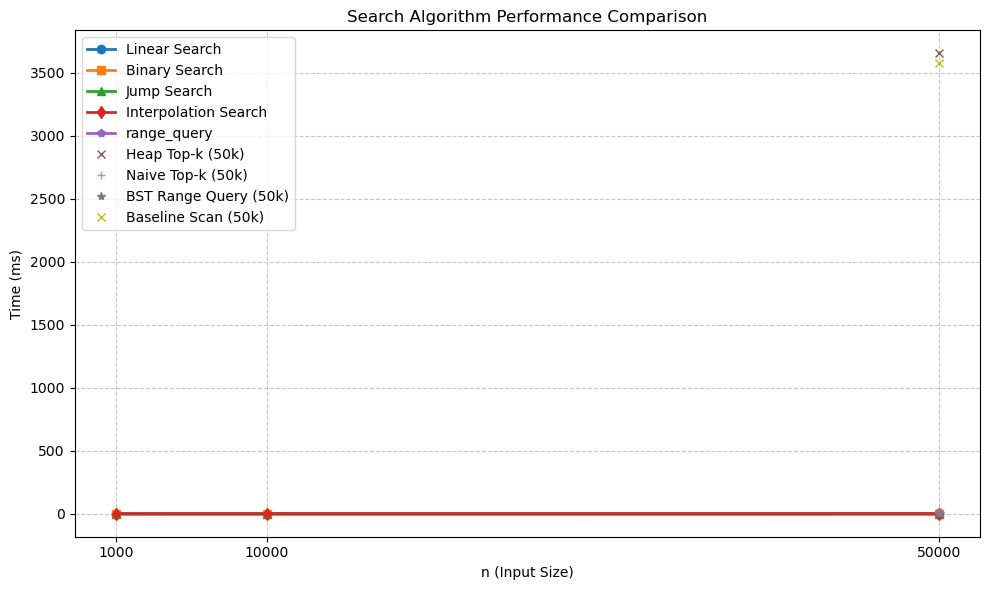

In [56]:
import matplotlib.pyplot as plt

n_values = [1000, 10000, 50000]

linear_search = linear_times
binary_search = binary_times
jump_search = jump_times
interpolation_search = interpolation_times
range_query = [None, None, 6.720400182530284]

plt.figure(figsize=(10, 6))


plt.plot(n_values, linear_search, marker='o', label='Linear Search', linewidth=2)
plt.plot(n_values, binary_search, marker='s', label='Binary Search', linewidth=2)
plt.plot(n_values, jump_search, marker='^', label='Jump Search', linewidth=2)
plt.plot(n_values, interpolation_search, marker='d', label='Interpolation Search', linewidth=2)
plt.plot(n_values, range_query, marker='p', label='range_query', linewidth=2)
plt.plot([50000], [heap_time], marker='x', label='Heap Top-k (50k)', linestyle='None')
plt.plot([50000], [naive_time], marker='+', label='Naive Top-k (50k)', linestyle='None')
plt.plot([50000], [bst_time], marker='*', label='BST Range Query (50k)', linestyle='None')
plt.plot([50000], [lazy_baseline_time], marker='x', label='Baseline Scan (50k)', linestyle='None')

plt.xlabel('n (Input Size)')
plt.ylabel('Time (ms)')
plt.title('Search Algorithm Performance Comparison')
plt.xticks(n_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Binary search is clearly the fastest across all sizes. At n = 50,000, it takes about 0.007 ms, while linear search is much slower at 1.95 ms. Interpolation search is also quite fast (~0.04 ms) and could be the best if the data were evenly spaced, but here it doesn’t beat binary. Linear search is the slowest overall, and jump search comes in second worst, sitting in the middle.

The BST range query is useful when you only need values in a certain range because it doesn’t check every element. Compared to the lazy baseline that scans everything, the BST version is much faster at n = 50,000 since it only looks at relevant parts of the tree.

For top-k, the heap approach is efficient since it only keeps track of the best 10 items. In this case, though, the CSV/pandas sort was slightly faster, probably because it’s highly optimized, even if the heap is better in theory.



In [57]:
bst_sorted = BinarySearchTree()

depths = []

for value in range(1, 1001):
    bst_sorted.insert(value, value)
    depths.append(bst_sorted.depth())

print(depths[:30])



[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


When I insert values in order (1 to 1000), the BST just keeps growing to the right, so it basically turns into a long chain instead of a tree. A better tree would keep itself balanced, so that it wouldn't lean to one side and stays more compact, which keeps operations fast.